<a href="https://colab.research.google.com/github/svyatoslavna/ml_hw/blob/main/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ДОМАШНЕЕ ЗАДАНИЕ

### **Задача:** повторите туториал на датасете **Iris**

**Датасет Iris:**
- 150 примеров цветков ириса
- 3 вида (Setosa, Versicolor, Virginica)
- 4 признака (длина/ширина чашелистика и лепестка)

### **Требования:**
1. **часть 1-2: анализ данных**
   - загрузите датасет `sklearn.datasets.load_iris()`
   - создайте 2 графика распределения классов
   - визуализируйте данные в 2D (выберите 2 любых признака)

2. **часть 3-5: подготовка и обучение**
   - разделите данные 70/30 с `stratify`
   - масштабируйте признаки
   - обучите SVM с линейным ядром

3. **часть 6: эксперименты**
   - попробуйте 3 разных значения C: 0.1, 1, 10
   - сравните accuracy каждой модели
   - выберите лучшую

4. **часть 7-8: оценка**
   - постройте матрицу ошибок для лучшей модели
   - вычислите precision, recall, F1-score
   - найдите и проанализируйте 2 примера ошибок

5. **часть 9: анализ**
   - постройте кривую обучения
   - ответьте: модель переобучается или недообучается?
   - что можно улучшить?

### **Формат сдачи:**
- **Colab ноутбук** с выполненным кодом
- **краткий отчет** (3-5 предложений) с выводами:
  - какая точность достигнута?
  - на каких классах чаще ошибается модель?
  - какие параметры SVM сработали лучше всего?

### **Критерии оценки:**
1. корректная загрузка и анализ данных
2. правильное разделение и масштабирование
3. обучение SVM с разными параметрами (показать, что вы делали как минимум 2 прогона с разными гиперпараметрами, 1 прогон даёт 1 балл)
4. визуализация матрицы ошибок
5. вычисление метрик precision, recall, F1
6. построение кривой обучения
7. представлены ответы на все вопросы из списка требований

### **Дедлайн:** 14 февраля, 23:59 в свои учебные репозитории

## Часть 1-2: Анализ данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import learning_curve

In [ ]:
# часть 1-2: анализ данных
# загрузите датасет sklearn.datasets.load_iris()

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Размер данных: {X.shape}")
print(f"Количество классов: {len(np.unique(y))}")
print(f"Названия классов: {target_names}")
print(f"Признаки: {feature_names}")

Размер данных: (150, 4)
Количество классов: 3
Названия классов: ['setosa' 'versicolor' 'virginica']
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
# проверяла, как можно по-другому

# df = load_iris(as_frame=True).frame
# df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
# df.head()

In [ ]:
df.rename(columns={'sepal length (cm)': 'sepal_length_cm',
                   'sepal width (cm)': 'sepal_width_cm',
                   'petal length (cm)': 'petal_length_cm',
                   'petal width (cm)': 'petal_width_cm'}, inplace=True)
feature_names = df.columns[:-1]

df.describe()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


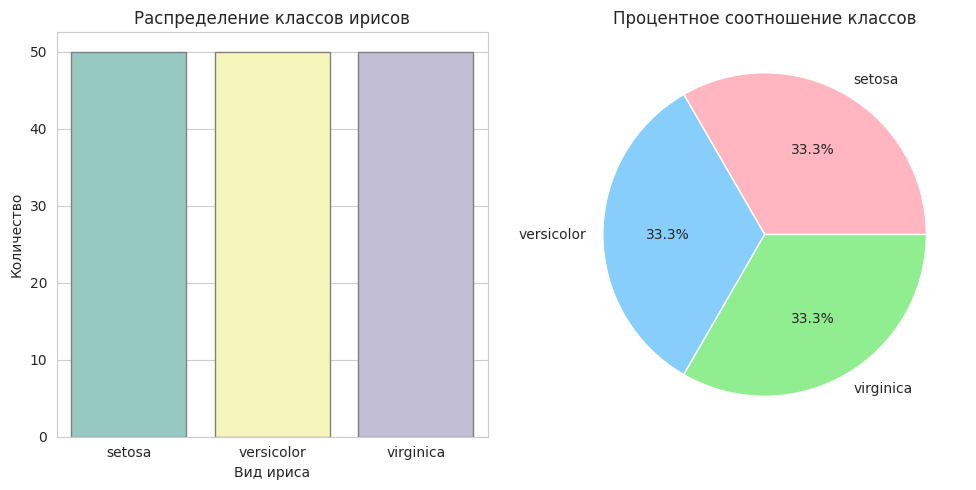

In [ ]:
# создайте 2 графика распределения классов

sns.set_style('whitegrid')

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='species', palette='Set3', hue='species', edgecolor='gray')
plt.title('Распределение классов ирисов')
plt.xlabel('Вид ириса')
plt.ylabel('Количество')


plt.subplot(1, 2, 2)
class_counts=df['target'].value_counts()
plt.pie(class_counts, labels=target_names, autopct='%1.1f%%', colors=['lightpink', 'lightskyblue', 'lightgreen'])
plt.title('Процентное соотношение классов')

plt.tight_layout()
plt.show()

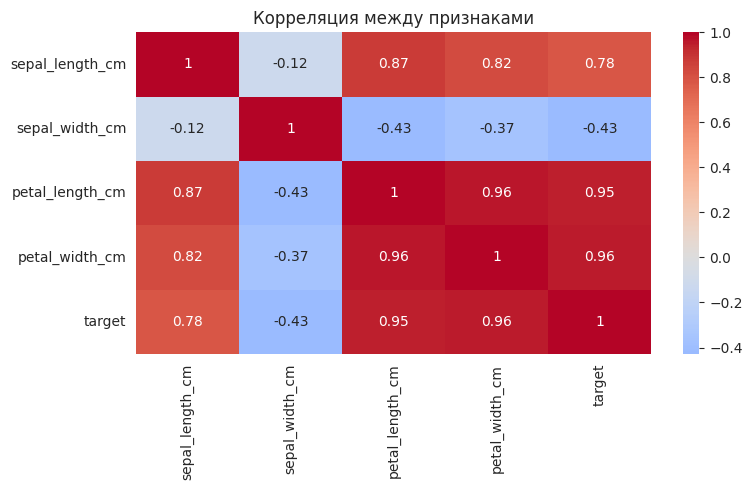

In [ ]:
plt.figure(figsize=(8,5))
corr_matrix = df[feature_names].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция между признаками')

plt.tight_layout()
plt.show()

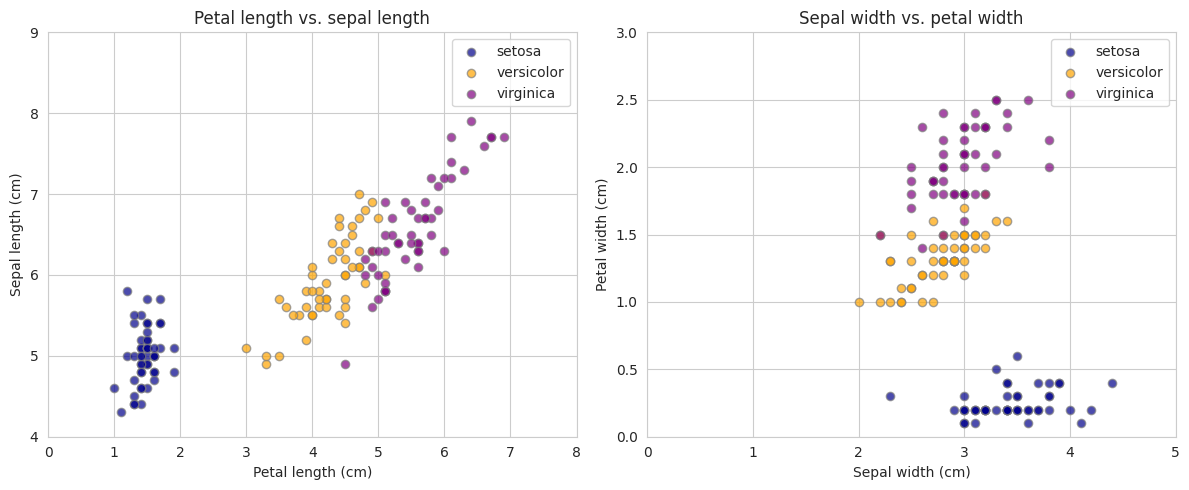

In [ ]:
# визуализируйте данные в 2D (выберите 2 любых признака)

# petal length vs. sepal length
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

colors = ['darkblue', 'orange', 'purple']

for i, iris_class in enumerate(target_names):
    plt.scatter(df[df['target'] == i]['petal_length_cm'],
                df[df['target'] == i]['sepal_length_cm'],
                label=iris_class, alpha=0.7, color=colors[i], edgecolor='gray')
plt.xlabel('Petal length (cm)')
plt.ylabel('Sepal length (cm)')
plt.legend()
plt.title('Petal length vs. sepal length')
plt.ylim(4, 9)
plt.xlim(0, 8)


# sepal width vs. petal_width
plt.subplot(1, 2, 2)
for i, iris_class in enumerate(target_names):
    plt.scatter(df[df['target'] == i]['sepal_width_cm'],
                df[df['target'] == i]['petal_width_cm'],
                label=iris_class, alpha=0.7, color=colors[i], edgecolor='gray')
plt.xlabel('Sepal width (cm)')
plt.ylabel('Petal width (cm)')
plt.legend()
plt.title('Sepal width vs. petal width')
plt.ylim(0, 3)
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

## Часть 3-5: Подготовка и обучение

In [ ]:
# разделите данные 70/30 с stratify

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Train size: (105, 4)
Test size: (45, 4)
Train class distribution: [35 35 35]
Test class distribution: [15 15 15]


In [ ]:
# масштабируйте признаки

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"До масштабирования (пример):\n {X_train[0, :]}")
print(f"После масштабирования (пример): \n {X_train_scaled[0, :]}")

До масштабирования (пример):
 [5.1 2.5 3.  1.1]
После масштабирования (пример): 
 [-0.90045861 -1.22024754 -0.4419858  -0.13661044]


In [ ]:
# обучите SVM с линейным ядром

svm_lin = SVC(kernel='linear', random_state=42) # C по умолчанию = 1
svm_lin.fit(X_train_scaled, y_train)
y_pred_lin = svm_lin.predict(X_test_scaled)
acc_lin = accuracy_score(y_test, y_pred_lin)

# стало интересно, какие получились веса, смещение, опорные векторы:
print(f"Веса: {svm_lin.coef_}")
print(f"Смещение: {svm_lin.intercept_}")
print(f"Всего опорных векторов: {len(svm_lin.support_vectors_)}")
print(f"\nAccuracy = {acc_lin:.2f}")

Веса: [[-0.37884737  0.257286   -0.89231535 -0.96132941]
 [-0.17767612  0.12308868 -0.49038696 -0.43860912]
 [ 0.05313018  0.24707152 -1.83492219 -2.43636428]]
Смещение: [-1.55282594 -0.27926088  2.74236513]
Всего опорных векторов: 21

Accuracy = 0.91


## Часть 6: Эксперименты

In [ ]:
# попробуйте 3 разных значения C: 0.1, 1, 10

# C = 0.1
svm_low_c = SVC(C=0.1, random_state=42) # по умолчанию kernel='rbf'
svm_low_c.fit(X_train_scaled, y_train)
y_pred_low_c = svm_low_c.predict(X_test_scaled)
acc_low_c = accuracy_score(y_test, y_pred_low_c)

In [ ]:
# C = 1
svm_norm_c = SVC(random_state=42) # по умолчанию kernel='rbf', C=1
svm_norm_c.fit(X_train_scaled, y_train)
y_pred_norm_c = svm_norm_c.predict(X_test_scaled)
acc_norm_c = accuracy_score(y_test, y_pred_norm_c)

In [ ]:
# C = 10
svm_high_c = SVC(C=10, random_state=42)
svm_high_c.fit(X_train_scaled, y_train)
y_pred_high_c = svm_high_c.predict(X_test_scaled)
acc_high_c = accuracy_score(y_test, y_pred_high_c)

In [ ]:
# сравните accuracy каждой модели
# выберите лучшую

print(f"Линейная SVM c C = 1:   Accuracy = {acc_lin:.2f}")
print(f"                        Всего опорных векторов: {len(svm_lin.support_vectors_)}\n")
print(f"RBF SVM с С = 1:      Accuracy = {acc_norm_c:.2f}")
print(f"                        Всего опорных векторов: {len(svm_norm_c.support_vectors_)}\n")
print(f"RBF SVM с С = 0.1:    Accuracy = {acc_low_c:.2f}")
print(f"                        Всего опорных векторов: {len(svm_low_c.support_vectors_)}\n")
print(f"RBF SVM с С = 10:     Accuracy = {acc_high_c:.2f}")
print(f"                        Всего опорных векторов: {len(svm_high_c.support_vectors_)}")

# две модели имеют одинаковую Accuracy, выбираю одну из них - RBF SVM с С = 1

Линейная SVM c C = 1:   Accuracy = 0.91
                        Всего опорных векторов: 21

RBF SVM с С = 1:      Accuracy = 0.93
                        Всего опорных векторов: 40

RBF SVM с С = 0.1:    Accuracy = 0.87
                        Всего опорных векторов: 87

RBF SVM с С = 10:     Accuracy = 0.93
                        Всего опорных векторов: 27


## Часть 7-8: Оценка


In [ ]:
# вычислите precision, recall, F1-score

print(f"Classification report для RBF SVM (C = 1) "
      f"c Accuracy = {acc_norm_c:.2f}:\n")
print(classification_report(y_test, y_pred_norm_c, target_names=target_names))

Classification report для RBF SVM (C = 1) c Accuracy = 0.93:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



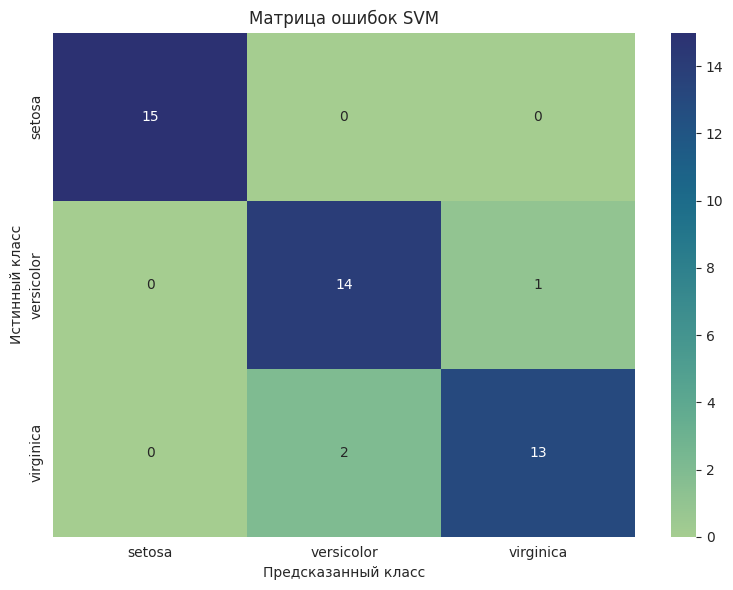

In [ ]:
# постройте матрицу ошибок для лучшей модели

cm = confusion_matrix(y_test, y_pred_norm_c)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок SVM')

plt.tight_layout()
plt.show()

In [ ]:
# найдите и проанализируйте 2 примера ошибок

error_indices = np.where(y_pred_norm_c != y_test)[0]

print(f"Количество ошибок: {len(error_indices)}\n")

if len(error_indices) > 0:
    for i, idx in enumerate(error_indices):
        print(f"Ошибка {i+1}:")
        print(f"  истинный класс: {target_names[y_test[idx]]}")
        print(f"  предсказанный:  {target_names[y_pred_norm_c[idx]]}")
        print(f"  вероятности классов: {svm_norm_c.decision_function(X_test_scaled[idx:idx+1])}")


Количество ошибок: 3

Ошибка 1:
  истинный класс: virginica
  предсказанный:  versicolor
  вероятности классов: [[-0.23090483  2.1971911   1.14875139]]
Ошибка 2:
  истинный класс: versicolor
  предсказанный:  virginica
  вероятности классов: [[-0.2288225   1.16919301  2.17891792]]
Ошибка 3:
  истинный класс: virginica
  предсказанный:  versicolor
  вероятности классов: [[-0.20965126  2.17902878  1.11615713]]


## Часть 9: Анализ

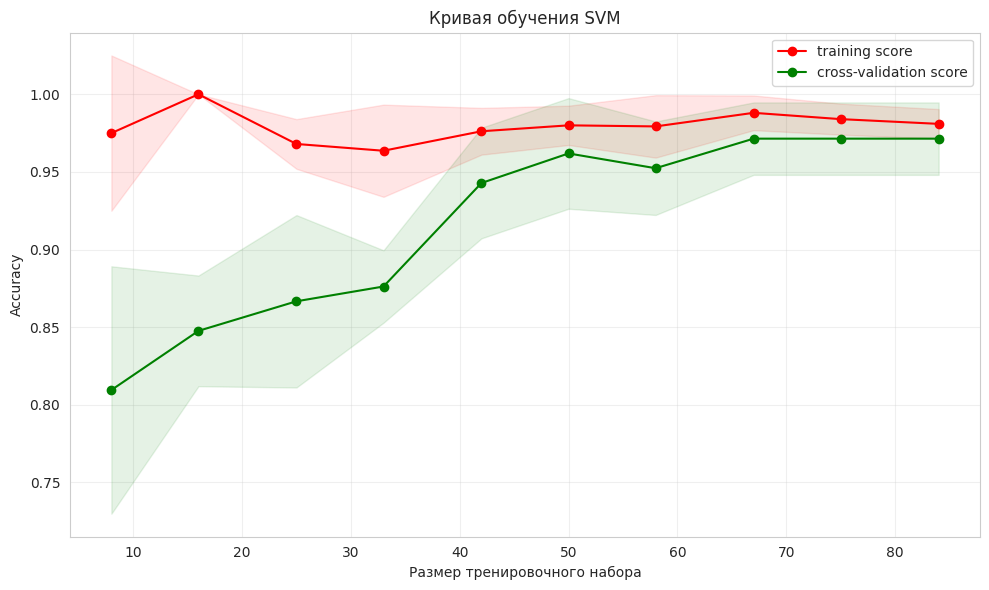

In [ ]:
# постройте кривую обучения

train_sizes, train_scores, test_scores = learning_curve(
    svm_norm_c, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel('Размер тренировочного набора')
plt.ylabel('Accuracy')
plt.title('Кривая обучения SVM')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**# ответьте: модель переобучается или недообучается?**

На основе кривой обучения можно сделать вывод о том, что модель НЕ переобучается и НЕ недообучается. Она хорошо обобщает,
так как кривые обучения сходятся к высокому значению точности
с минимальным разрывом между обучающей и валидационной выборками.

**# что можно улучшить?**

Данная модель уже достигла достаточно высокой точности, кажется, дальнейшие улучшения будут не больше чем на пару процентов точности (даже идеальная модель не всегда дает 100% Accuracy, т.к. в данных обычно есть шум). Стремиться к идеалу можно засчёт увеличения количества данных или путем настройки гиперпараметров.

**# какая точность достигнута?**
* Линейная SVM c C = 1:   Accuracy = 0.91

* RBF SVM с С = 0.1:    Accuracy = 0.87

* RBF SVM с С = 1:      **Accuracy = 0.93**

* RBF SVM с С = 10:     **Accuracy = 0.93**

Максимальная точность была достигнута на RBF SVM с С = 1 и RBF SVM с С = 10 (**93%**).


**# на каких классах чаще ошибается модель?**

Модель RBF SVM с С = 1 ошиблась дважды на virginica, один раз - на versicolor.

**# какие параметры SVM сработали лучше всего?**

Из тех немногочисленных моделей, что были протестированы, лучше всего сработали SVM c RBF ядром и **НЕ**низким С, С=1 или С=10.

# ТУТОРИАЛ: SVM ДЛЯ КЛАССИФИКАЦИИ ДАННЫХ

## Часть 0: настройка окружения

In [ ]:
# установка необходимых библиотек
!pip install numpy pandas matplotlib seaborn scikit-learn

# импорт
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

---

## Часть 1: загрузка и знакомство с данными

In [ ]:
# загружаем датасет
wine = datasets.load_wine()
X = wine.data  # признаки (13 химических показателей)
y = wine.target  # классы (0, 1, 2 - регионы происхождения)
feature_names = wine.feature_names
target_names = wine.target_names

print(f"размер данных: {X.shape}")
print(f"количество классов: {len(np.unique(y))}")
print(f"названия классов: {target_names}")
print(f"признаки: {feature_names}")

размер данных: (178, 13)
количество классов: 3
названия классов: ['class_0' 'class_1' 'class_2']
признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


**Вопрос для анализа:**
```
Какой тип классификации предстоит решить?
A. бинарная классификация (2 класса)
B. многоклассовая классификация (3 класса) !!!!!
C. мультилейбл классификация (несколько меток одновременно)
D. ординальная классификация (упорядоченные классы)
```

---

## Часть 2: изучение данных с графиками

In [ ]:
# создаем DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['wine_type'] = df['target'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})

# первые 5 строк
print(df.head())

# базовая статистика
print(df.describe())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target wine_type  
0

/tmp/ipython-input-1934804563.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='wine_type', data=df, palette='Set2')


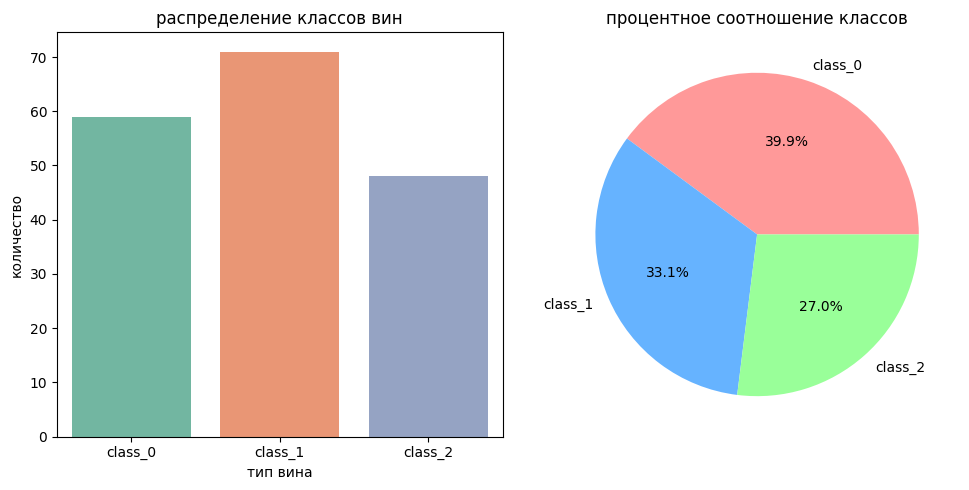

In [ ]:
plt.figure(figsize=(10, 5))

# гистограмма по классам
plt.subplot(1, 2, 1)
sns.countplot(x='wine_type', data=df, palette='Set2')
plt.title('распределение классов вин')
plt.xlabel('тип вина')
plt.ylabel('количество')

# круговая диаграмма
plt.subplot(1, 2, 2)
class_counts = df['target'].value_counts()
plt.pie(class_counts, labels=target_names, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('процентное соотношение классов')

plt.tight_layout()
plt.show()

**Вопрос для анализа:**
```
На основе визуализации распределения классов, какой вывод можно сделать?
A. данные сильно несбалансированы (один класс доминирует)
B. данные умеренно сбалансированы (разница между классами не критична)
C. данные идеально сбалансированы (одинаковое количество примеров)
D. нельзя определить баланс без дополнительной информации
```

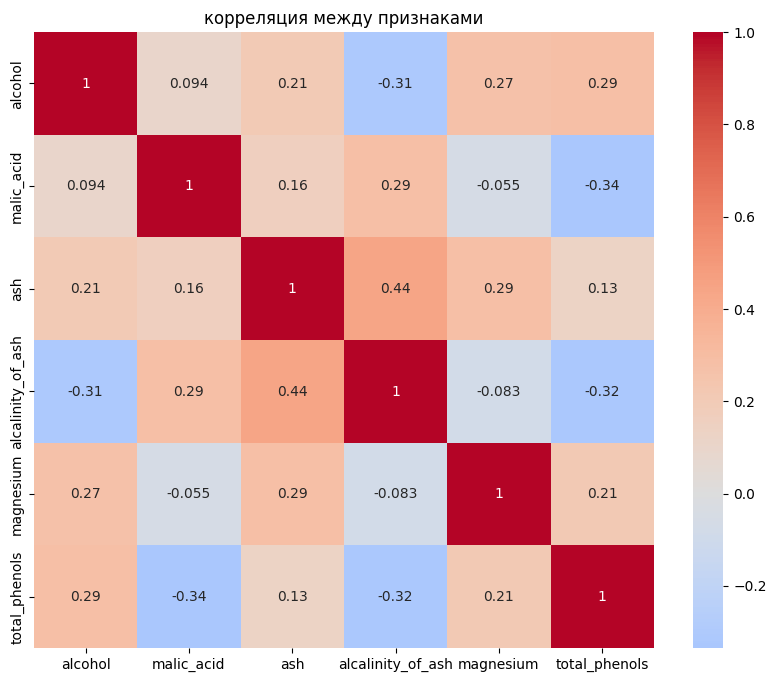

In [ ]:
# корреляционная матрица (первые 6 признаков для наглядности)
plt.figure(figsize=(10, 8))
corr_matrix = df[feature_names[:6]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('корреляция между признаками')
plt.show()

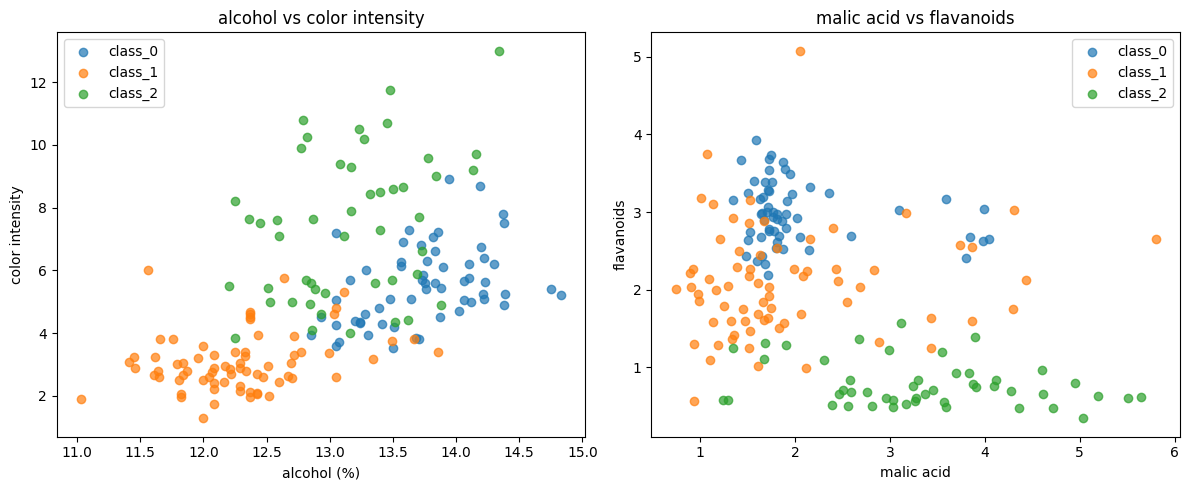

In [ ]:
# берем два самых информативных признака (по описанию датасета)
plt.figure(figsize=(12, 5))

# alcohol vs color intensity
plt.subplot(1, 2, 1)
for i, wine_class in enumerate(target_names):
    plt.scatter(df[df['target'] == i]['alcohol'],
                df[df['target'] == i]['color_intensity'],
                label=wine_class, alpha=0.7)
plt.xlabel('alcohol (%)')
plt.ylabel('color intensity')
plt.legend()
plt.title('alcohol vs color intensity')

# malic acid vs flavanoids
plt.subplot(1, 2, 2)
for i, wine_class in enumerate(target_names):
    plt.scatter(df[df['target'] == i]['malic_acid'],
                df[df['target'] == i]['flavanoids'],
                label=wine_class, alpha=0.7)
plt.xlabel('malic acid')
plt.ylabel('flavanoids')
plt.legend()
plt.title('malic acid vs flavanoids')

plt.tight_layout()
plt.show()

**Вопрос для анализа:**
```
Основываясь на 2D визуализации данных, какой вывод наиболее верен?
A. классы линейно разделимы в 2D пространстве выбранных признаков
B. классы полностью перекрываются, разделение невозможно
C. классы частично разделимы, но потребуется многомерная граница
D. данные содержат явные выбросы, мешающие анализу
```

---

## Часть 3: математические основы SVM

### 3.1 что такое SVM? понимание через аналогии

**SVM (Support Vector Machine, метод опорных векторов)** — это алгоритм, который находит **оптимальную границу** между классами.

**Представьте:**
- у вас есть два типа шариков на столе: красные и синие
- вы хотите провести линию, которая их разделяет
- таких линий можно провести бесконечно много
- SVM выбирает **линию с максимальным запасом** от ближайших шариков каждой группы

### 3.2 ключевые компоненты SVM

#### **Support vectors (опорные векторы)**
- это самые "сложные" точки данных — те, которые находятся ближе всего к разделяющей границе
- именно они "поддерживают" (support) границу
- если убрать все остальные точки, граница останется прежней
- в реальности: пациенты с пограничными анализами, отзывы с неявной тональностью

#### **Margin (зазор)**
- расстояние от разделяющей линии до ближайших точек каждого класса
- чем больше зазор — тем устойчивее модель к шуму в данных
- SVM специально **максимизирует этот зазор** (maximum margin classifier)

#### **Hyperplane (гиперплоскость)**
- в 2D: линия (y = kx + b)
- в 3D: плоскость
- в n-мерном пространстве: (n-1)-мерная "плоскость", разделяющая пространство
- математически: w₁x₁ + w₂x₂ + ... + wₙxₙ + b = 0

### 3.3 как SVM работает в многомерных пространствах?

**Проблема:** в реальных данных признаки могут быть неразделимы прямой линией в исходном пространстве.

**Решение SVM: ядерный трюк (kernel trick)**

1. **Неявное преобразование:** данные переводятся в пространство более высокой размерности
2. **Магия вычислений:** SVM вычисляет скалярные произведения в новом пространстве, не вычисляя само преобразование
3. **Результат:** в новом пространстве данные становятся линейно разделимыми

**Пример:** представьте, что у вас есть круг красных точек внутри кольца синих. В 2D их нельзя разделить прямой, но если добавить третье измерение (расстояние от центра), они становятся разделимыми плоскостью.

### 3.4 основные типы ядер (kernels)

**Ядро** — функция, которая позволяет SVM работать с нелинейно разделимыми данными:

- **Линейное ядро:** для линейно разделимых данных (самый простой случай)
- **Полиномиальное ядро:** добавляет полиномиальные комбинации признаков
- **RBF (радиально-базисное ядро):** наиболее популярное, создает сложные нелинейные границы
- **Сигмоидное ядро:** похоже на нейронную сеть

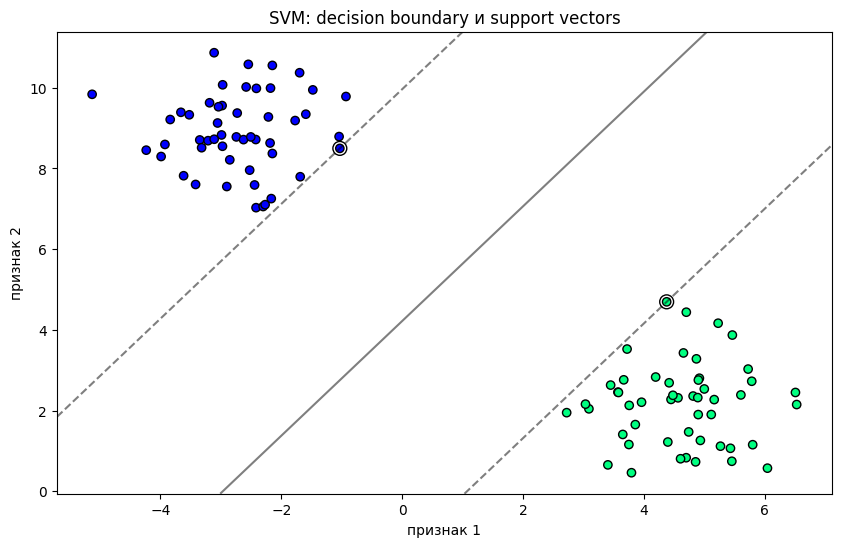

In [ ]:
# визуализация для понимания
from sklearn.datasets import make_blobs

# создаем искусственные данные
X_visual, y_visual = make_blobs(n_samples=100, centers=2, random_state=42)

# обучаем SVM
svm_visual = SVC(kernel='linear')
svm_visual.fit(X_visual, y_visual)

# функция для визуализации SVM
def plot_svm_boundary(model, X, y):
    plt.figure(figsize=(10, 6))

    # точки данных
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k')

    # decision boundary
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # сетка для построения границы
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # граница и margin
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=100, linewidth=1, facecolors='none', edgecolors='k')

    plt.xlabel('признак 1')
    plt.ylabel('признак 2')
    plt.title('SVM: decision boundary и support vectors')
    plt.show()

plot_svm_boundary(svm_visual, X_visual, y_visual)

**Вопрос для анализа:**
```
В контексте SVM, какие утверждения верны о support vectors?
A. это все точки обучающей выборки
B. это точки, наиболее удаленные от разделяющей гиперплоскости
C. это точки, лежащие на границе зазора или внутри него
D. удаление support vectors не изменяет разделяющую гиперплоскость
E. количество support vectors обратно пропорционально степени регуляризации
```

---

## Часть 4: подготовка данных для SVM

In [ ]:
# разделяем данные (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train size: {X_train.shape}")
print(f"test size: {X_test.shape}")
print(f"train class distribution: {np.bincount(y_train)}")
print(f"test class distribution: {np.bincount(y_test)}")

train size: (142, 13)
test size: (36, 13)
train class distribution: [47 57 38]
test class distribution: [12 14 10]


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # только transform, не fit!

print("пример до масштабирования (первые 3 признака):")
print(X_train[0, :3])
print("\nпример после масштабирования (первые 3 признака):")
print(X_train_scaled[0, :3])

пример до масштабирования (первые 3 признака):
[13.28  1.64  2.84]

пример после масштабирования (первые 3 признака):
[ 0.38580089 -0.63787118  1.77666817]


**Вопрос для анализа:**
```
Почему масштабирование признаков критично для SVM?
A. SVM использует расстояния между точками, которые зависят от масштаба признаков
B. ядро RBF чувствительно к абсолютным значениям признаков
C. градиентные методы оптимизации сходятся медленнее без масштабирования
D. регуляризация параметра C действует по-разному на признаки разного масштаба
```

---

## Часть 5: обучение SVM

In [ ]:
# создаем и обучаем модель
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

# предсказания
y_pred_linear = svm_linear.predict(X_test_scaled)

# оценка
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"линейный SVM accuracy: {accuracy_linear:.2%}")
print("\nclassification report:")
print(classification_report(y_test, y_pred_linear, target_names=target_names))

линейный SVM accuracy: 94.44%

classification report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



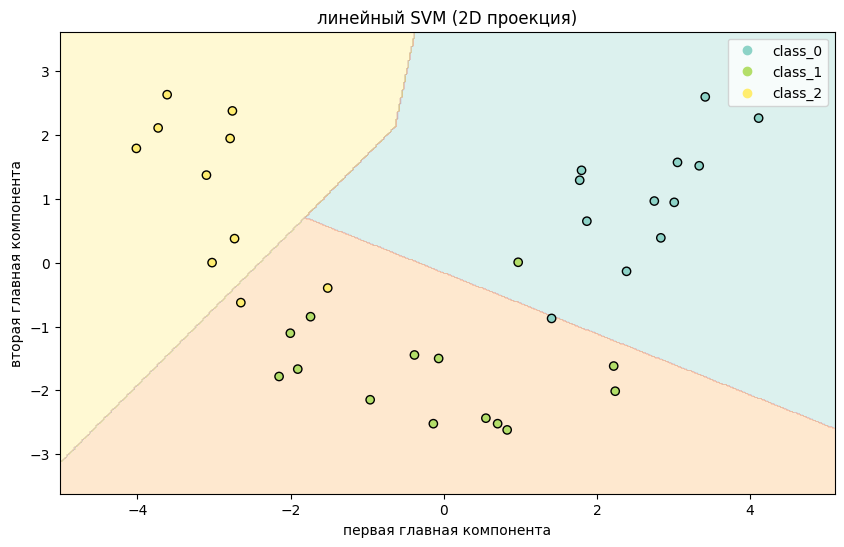

In [ ]:
# используем PCA для уменьшения до 2D для визуализации
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

# создаем сетку для границы
def plot_decision_boundary_2d(model, X, y, title):
    h = .02  # шаг сетки
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # предсказание для каждой точки сетки
    Z = model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set3')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='Set3')
    plt.xlabel('первая главная компонента')
    plt.ylabel('вторая главная компонента')
    plt.title(title)
    plt.legend(handles=scatter.legend_elements()[0], labels=list(target_names))
    plt.show()

plot_decision_boundary_2d(svm_linear, X_test_pca, y_test, "линейный SVM (2D проекция)")

---

## Часть 6: меняем и переобучаем

In [ ]:
# SVM с RBF ядром (по умолчанию)
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"RBF SVM accuracy: {accuracy_rbf:.2%}")

RBF SVM accuracy: 97.22%


### 6.2 подбор параметров C и gamma

**Что такое гиперпараметры?**
- параметры, которые задаются до обучения модели
- не обучаются на данных, а выбираются экспериментально
- контролируют поведение и сложность модели

**Гиперпараметры SVM:**

**C (параметр регуляризации):**
- контролирует компромисс между точностью на обучающих данных и обобщающей способностью
- **маленькое C:** большая регуляризация → допускаем ошибки на обучающих данных ради большего зазора и лучшего обобщения
- **большое C:** маленькая регуляризация → стремимся правильно классифицировать все обучающие точки, рискуя переобучиться
- аналогия: C — это "строгость учителя". Маленькое C: учитель разрешает некоторые ошибки. Большое C: учитель требует идеального выполнения

**gamma (параметр ядра RBF):**
- определяет "радиус влияния" одной точки
- **маленькое gamma:** каждая точка имеет большое влияние → плавная граница решений
- **большое gamma:** точки имеют малое влияние → граница следует за отдельными точками, может стать извилистой
- аналогия: gamma — это "фокус зрения". Маленькое gamma: видим общую картину. Большое gamma: фокусируемся на деталях

C=0.01: accuracy = 38.89%
C=0.1: accuracy = 97.22%
C=1: accuracy = 97.22%
C=10: accuracy = 94.44%
C=100: accuracy = 94.44%


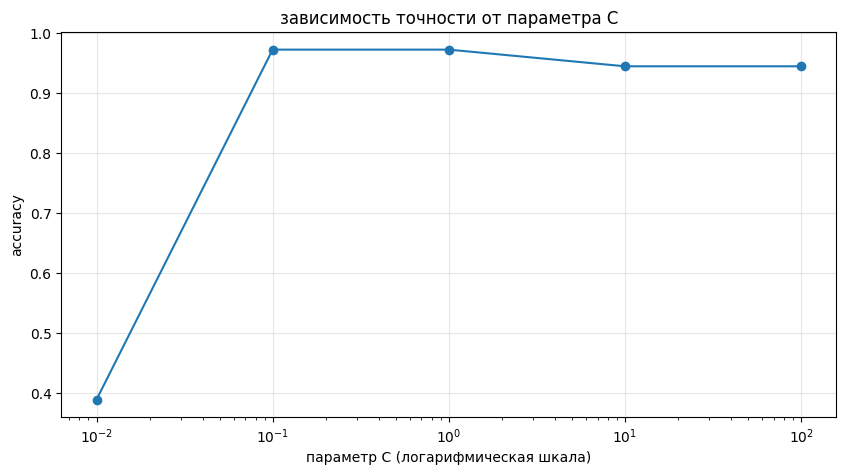

In [ ]:
# пробуем разные значения C
C_values = [0.01, 0.1, 1, 10, 100]
accuracies = []

for C in C_values:
    svm_temp = SVC(kernel='rbf', C=C, random_state=42)
    svm_temp.fit(X_train_scaled, y_train)
    acc = svm_temp.score(X_test_scaled, y_test)
    accuracies.append(acc)
    print(f"C={C}: accuracy = {acc:.2%}")

# график зависимости accuracy от C
plt.figure(figsize=(10, 5))
plt.plot(C_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel('параметр C (логарифмическая шкала)')
plt.ylabel('accuracy')
plt.title('зависимость точности от параметра C')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# используем найденные лучшие параметры
best_svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
best_svm.fit(X_train_scaled, y_train)

y_pred_best = best_svm.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"лучшая SVM accuracy: {accuracy_best:.2%}")

лучшая SVM accuracy: 94.44%


**Вопрос для анализа:**
```
Как параметр C влияет на поведение SVM?
A. большие значения C приводят к большей регуляризации и большему зазору
B. малые значения C допускают больше ошибок на обучающей выборке ради большего зазора
C. C не влияет на положение разделяющей гиперплоскости, только на скорость обучения
D. оптимальное значение C всегда равно 1 для стандартизованных данных
```

---

## Часть 7: матрица ошибок и метрики

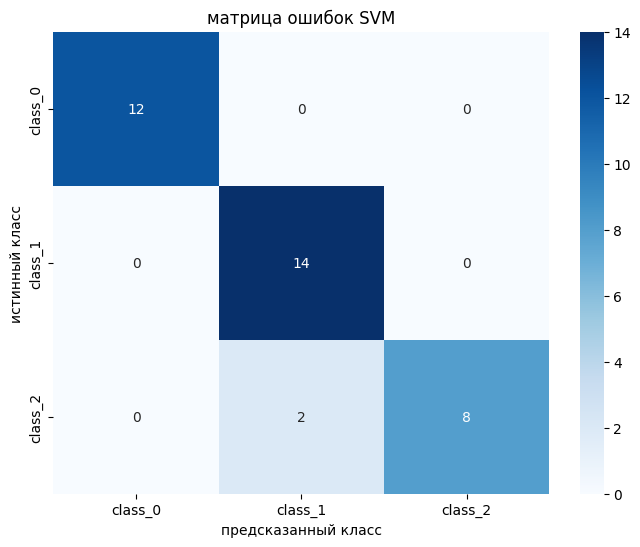

In [ ]:
# вычисляем матрицу ошибок
cm = confusion_matrix(y_test, y_pred_best)

# визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('предсказанный класс')
plt.ylabel('истинный класс')
plt.title('матрица ошибок SVM')
plt.show()

In [ ]:
print("детальный отчет по классификации:")
print(classification_report(y_test, y_pred_best, target_names=target_names))

# вычисляем дополнительные метрики вручную
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print(f"\nитоговые метрики:")
print(f"precision: {precision:.2%}  # точность (сколько из предсказанных правильные)")
print(f"recall:    {recall:.2%}    # полнота (сколько из реальных нашли)")
print(f"F1-score:  {f1:.2%}     # баланс precision и recall")

детальный отчет по классификации:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36


итоговые метрики:
precision: 95.14%  # точность (сколько из предсказанных правильные)
recall:    94.44%    # полнота (сколько из реальных нашли)
F1-score:  94.32%     # баланс precision и recall


**Вопрос для анализа:**
```
При оценке многоклассового классификатора, какие метрики наиболее информативны?
A. только accuracy, так как она дает общую картину
B. precision и recall для каждого класса в отдельности
C. macro-averaged метрики, которые дают равный вес каждому классу
D. weighted метрики, которые учитывают распределение классов
E. confusion matrix для визуального анализа ошибок
```

---

## Часть 8: анализ ошибок

In [ ]:
# находим индексы ошибок
error_indices = np.where(y_pred_best != y_test)[0]

print(f"количество ошибок: {len(error_indices)}")

if len(error_indices) > 0:
    print("\nпримеры ошибок:")

    for i, idx in enumerate(error_indices[:3]):  # покажем первые 3
        print(f"\nошибка {i+1}:")
        print(f"  истинный класс: {target_names[y_test[idx]]}")
        print(f"  предсказанный:  {target_names[y_pred_best[idx]]}")
        print(f"  вероятности классов: {best_svm.decision_function(X_test_scaled[idx:idx+1])}")

количество ошибок: 2

примеры ошибок:

ошибка 1:
  истинный класс: class_2
  предсказанный:  class_1
  вероятности классов: [[-0.21545195  2.17921522  1.13311604]]

ошибка 2:
  истинный класс: class_2
  предсказанный:  class_1
  вероятности классов: [[-0.19428459  2.16299388  1.10191035]]


In [ ]:
print(f"количество support vectors: {len(best_svm.support_vectors_)}")
print(f"количество support vectors по классам: {best_svm.n_support_}")
print(f"процент точек, являющихся support vectors: {len(best_svm.support_vectors_)/len(X_train):.1%}")

количество support vectors: 57
количество support vectors по классам: [16 24 17]
процент точек, являющихся support vectors: 40.1%


---

## Часть 9: график обучения (learning curve)

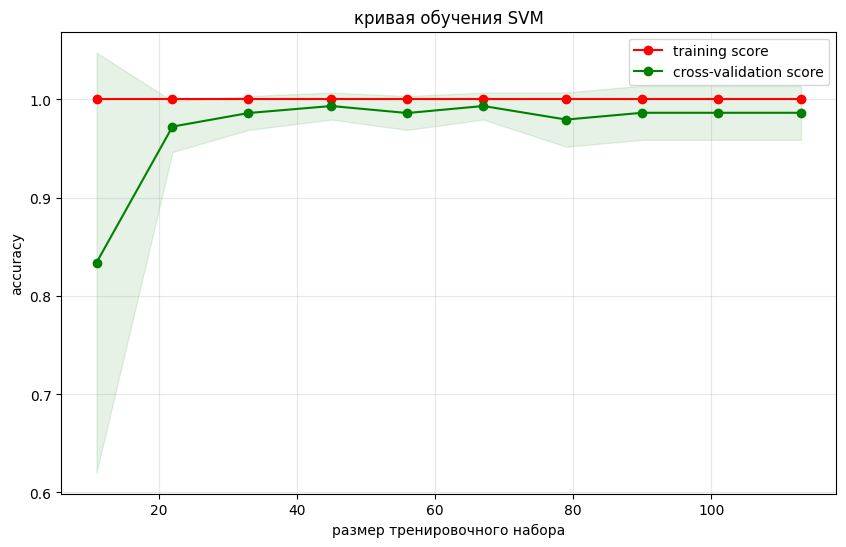

In [ ]:
from sklearn.model_selection import learning_curve

# вычисляем learning curve
train_sizes, train_scores, test_scores = learning_curve(
    best_svm, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# средние значения
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# график
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel('размер тренировочного набора')
plt.ylabel('accuracy')
plt.title('кривая обучения SVM')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

**Вопрос для анализа:**
```
На основе кривой обучения, какой вывод можно сделать о модели?
A. модель недообучается (обе кривые сходятся к низкому значению)
B. модель переобучается (большой разрыв между кривыми)
C. модель хорошо обобщает (кривые сходятся к высокому значению)
D. для улучшения нужны больше данных (кривые еще не сошлись)
```

---

# Конспект

[Презентация](https://docs.google.com/presentation/d/1zvrXR-cEpx7c911IPZFmLzfHVB1duPkArSK6xHEpeeM/edit?slide=id.p#slide=id.p)

**ТРИ ТИПА ОБУЧЕНИЯ. КЛАССИФИКАЦИЯ**

**1. Supervised (с учителем)**

*feature-based*

* Данные: (X, Y) где Y — правильный ответ

* Задача: научиться предсказывать Y по X

* Пример: спам-фильтр (письмо > спам/не спам)



**3. Reinforcement (с подкреплением)**

*НЕ feauture-based*

* Нет исходных данных

* Агент, среда, награда (reward)

* Позитивное/негативное подкрепление

* Задача: научиться стратегии, максимизирующей награду

* Политика: если собака падает - мы даем -1 балл, если встает - +1 балл.

* Пример: обучение робота ходить


**ТИПЫ КЛАССИФИКАЦИИ**
1. **Бинарная**: 2 класса (да/нет, спам/не спам)

2. **Многоклассовая**: 3+ класса
3. **Мультилейбл**: объект может принадлежать нескольким классам одновременно



**Дискриминирующие модели**

* определяют границы между классами
* SVM, логистическая регрессия, деревья решений
* SVM строит разделяющую плоскость:

**SVM**

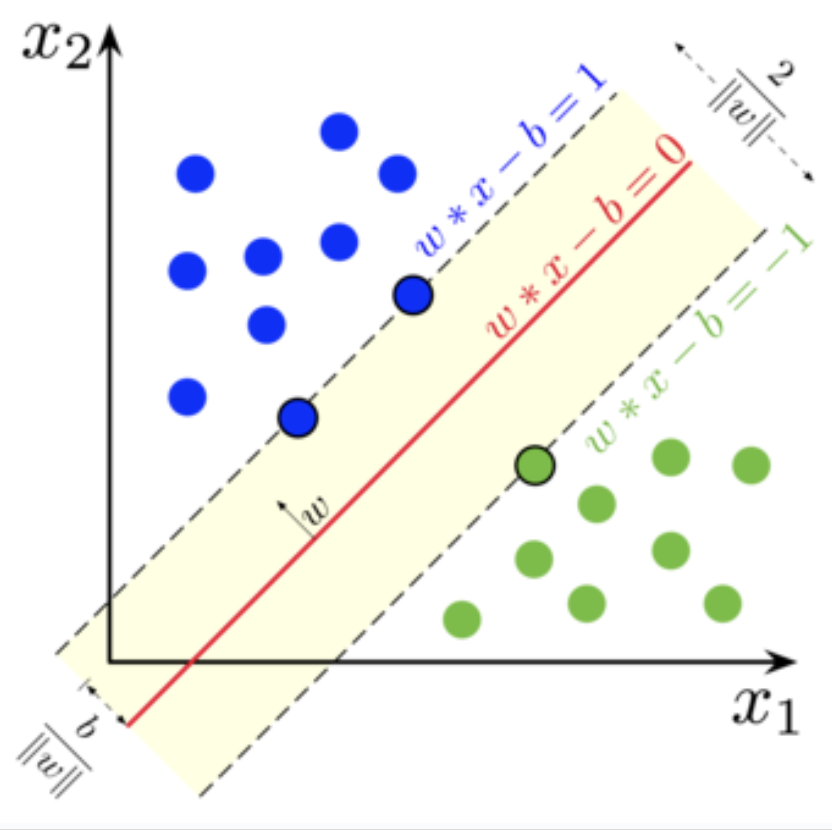

Каждая из точек = вектор.

Пограничные вектора - самые крайние примеры из классов (например: спам-текст, очень похожий на не-спам, + не-спам, похожий на спам).

Задача SVM найти support vectors и с их помощью построить гиперплоскость, разделяющую классы.

Margin - пунктирная линия, границы границы (гиперплоскости)

**Линейность**

* SVM - линейная модель (строит линейную функцию, которая “рисует” прямую).

* Данные не всегда заданы линейно, поэтому применяется kernel trick: ядерная функция вычисляет сходство
между парами значения в пространстве
большей размерности (например, 2D
представляется как 3D, где разделение
возможно)
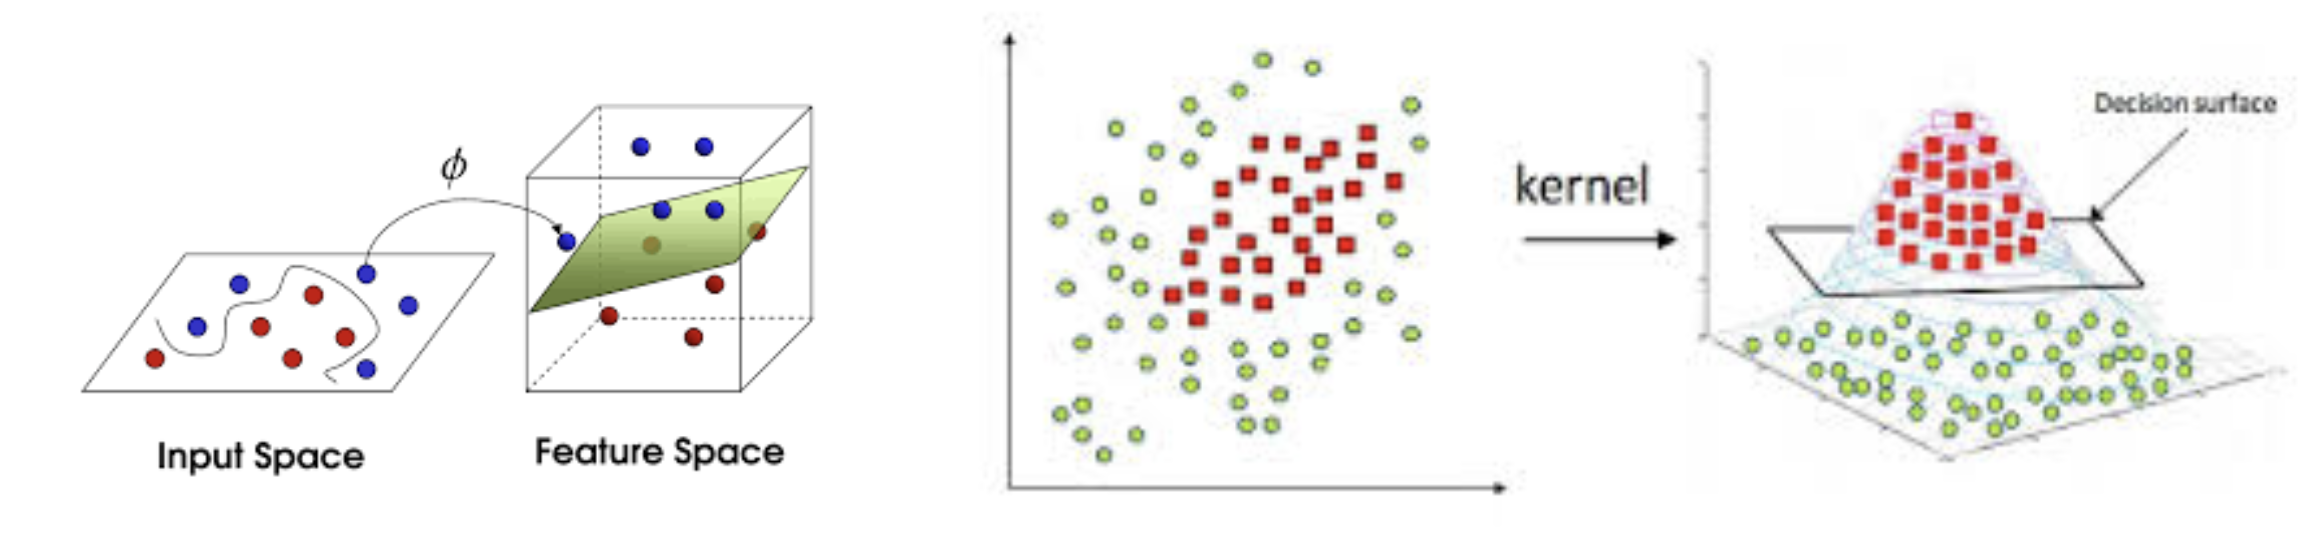

Ядро – это математическая функция, на основе которой производится повышение размерности (как мы удостоверимся, что эта 3D проекция соответствует исходному 2D представлению?)
Типы: линейное, полиномиальное, RBF, сигмоида (в этом примере RBF дает лучший результат)
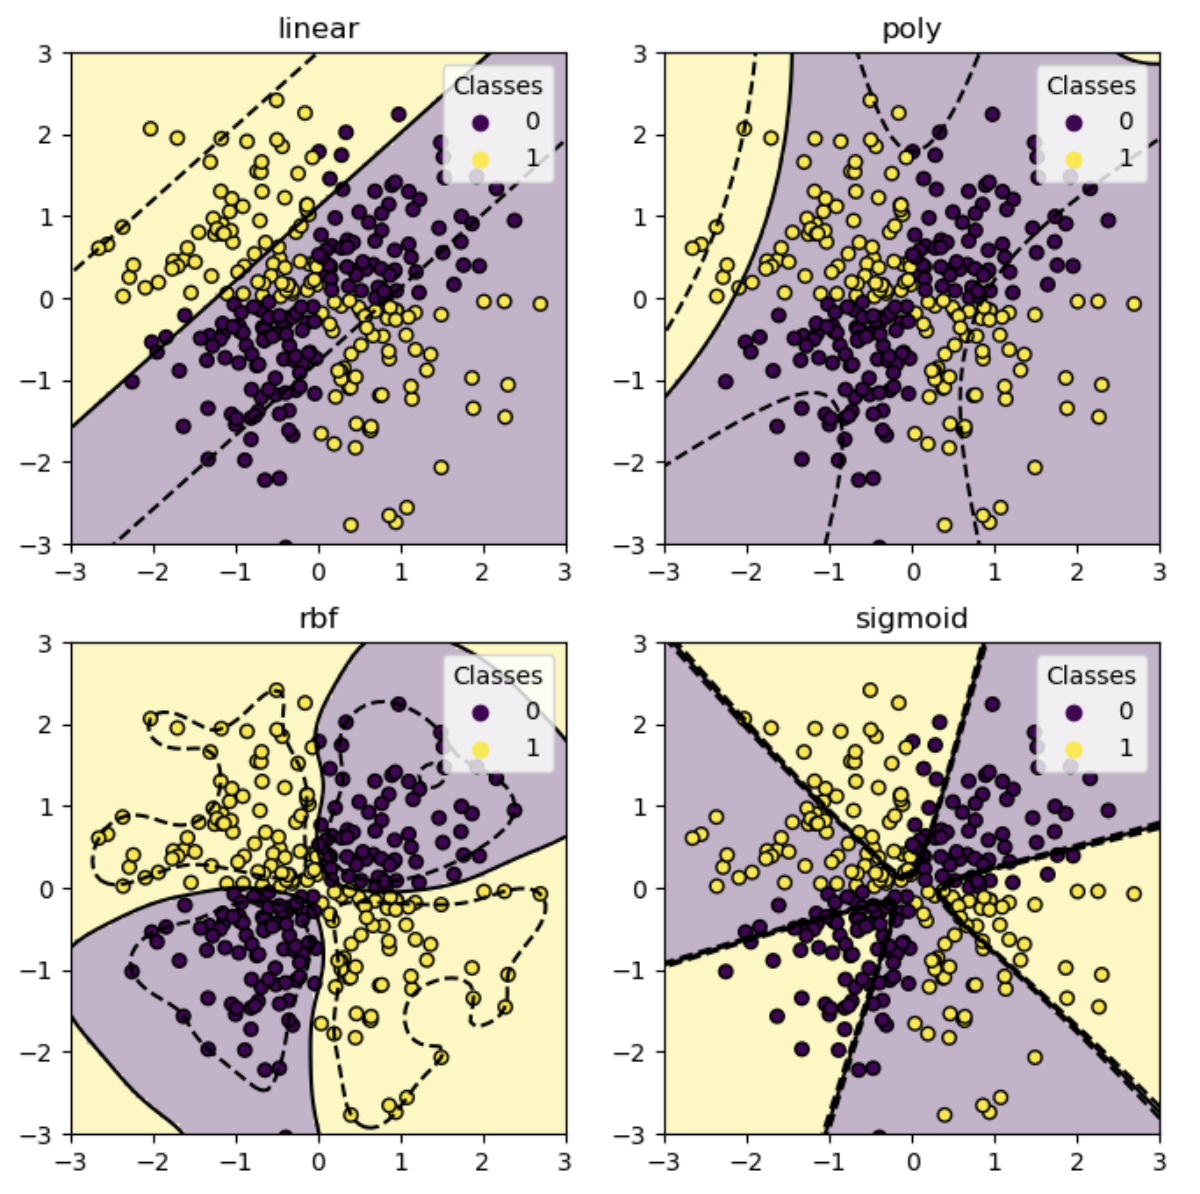

**Гиперпараметры**

> Это параметры (настройки машинного обучения), которые задаются ДО обучения


* ***C*** - параметр регуляризации
  * Маленькое C: большая регуляризация, допускаем ошибки ради лучшего обобщения
  * Большое C: слабая регуляризация, стремимся к идеальной классификации обучающих данных
* ***gamma*** - параметр ядра RBF (RBF производит увеличение размерности на основе вычисления расстояния между точками: gamma задаёт радиус влияния точек)
  * Маленькая gamma: широкое влияние точек, граница “грубая”, ближе к виду линейной
  * Большая gamma: локальное влияние точек, точная граница, “извилистая”



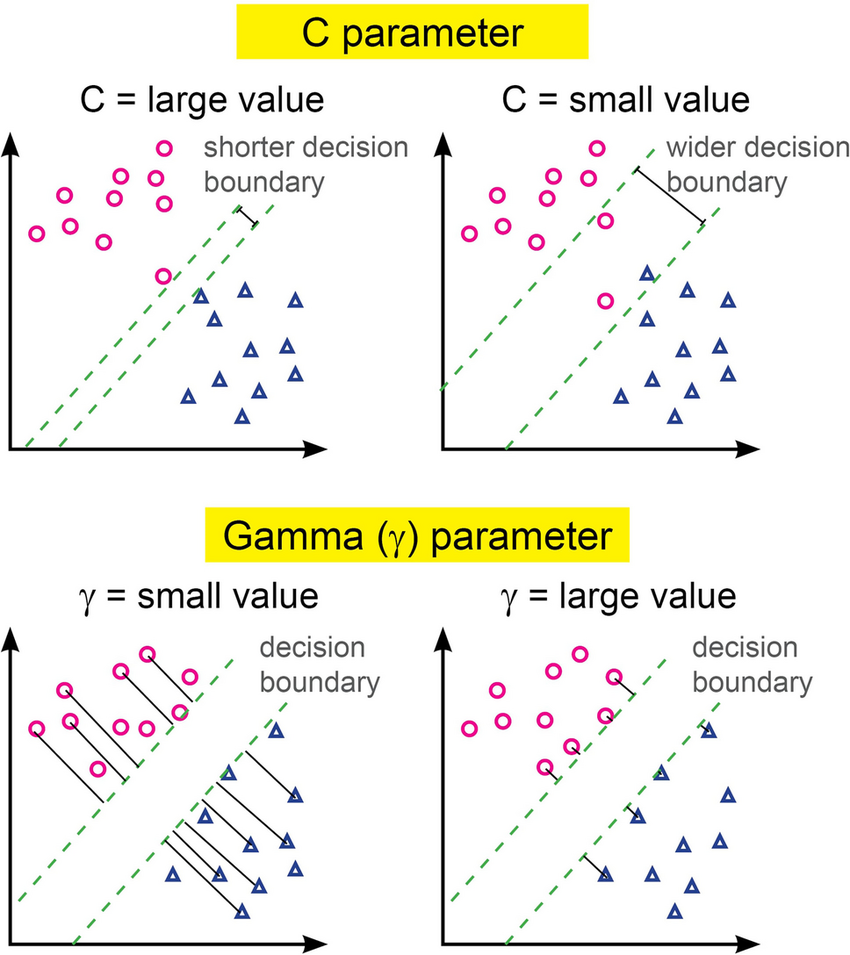

**Support Vector Machines**

* Интересный факт: алгоритм на основе SVM выиграл первый конкурс по распознаванию рукописных цифр (MNIST) в 1998 году

* Формальная задача: найти гиперплоскость,
которая разделяет классы

* Компоненты:

  * Гиперплоскость (выделена желтым)   *см.картинку выше*

  * Support vectors (пограничные точки)

  * Margin (граница, пунктирная линия)


**Генеративные модели** *(в противовес дискриминирующим, SVM - дискриминирующая, про генеративные - это уже другая тема)*
*   Моделирует распределения
*   Наивный Байес, LDA

* Наивный Байес моделирует распределения внутри каждого класса, а потом сравнивает схожесть данного объекта с каждым классом

* Чаще генеративные модели используются для порождающих моделей (генерация текста)

* Идея: если ты знаешь, как выстраиваются слова в научных статьях, сможешь выстроить новую статью из “конструктора” такой модели

* Плохо подходит для классификации!




**Балансировка классов. Методы**

На уровне данных:

* **Undersampling**: удаляем примеры мажоритарного класса
* **Oversampling**: дублируем примеры миноритарного класса
* **SMOTE**: создаем синтетические примеры

На уровне алгоритма:

* **Взвешивание классов**: штраф за ошибку на редком классе

**Оценка классификаторов**

* Метрика для сбалансированных данных:
  * **Accuracy**: (TP + TN) / Всего примеров

* Метрики для несбалансированных данных:
  * **Precision**: TP / (TP + FP) — "точность"
  * **Recall**: TP / (TP + FN) — "полнота"
  * **F1-score:** гармоническое среднее Precision и Recall
  * **Confusion Matrix**: матрица ошибок (показывает соотношение TP, TN, FP, FN; стремимся к диагонали)


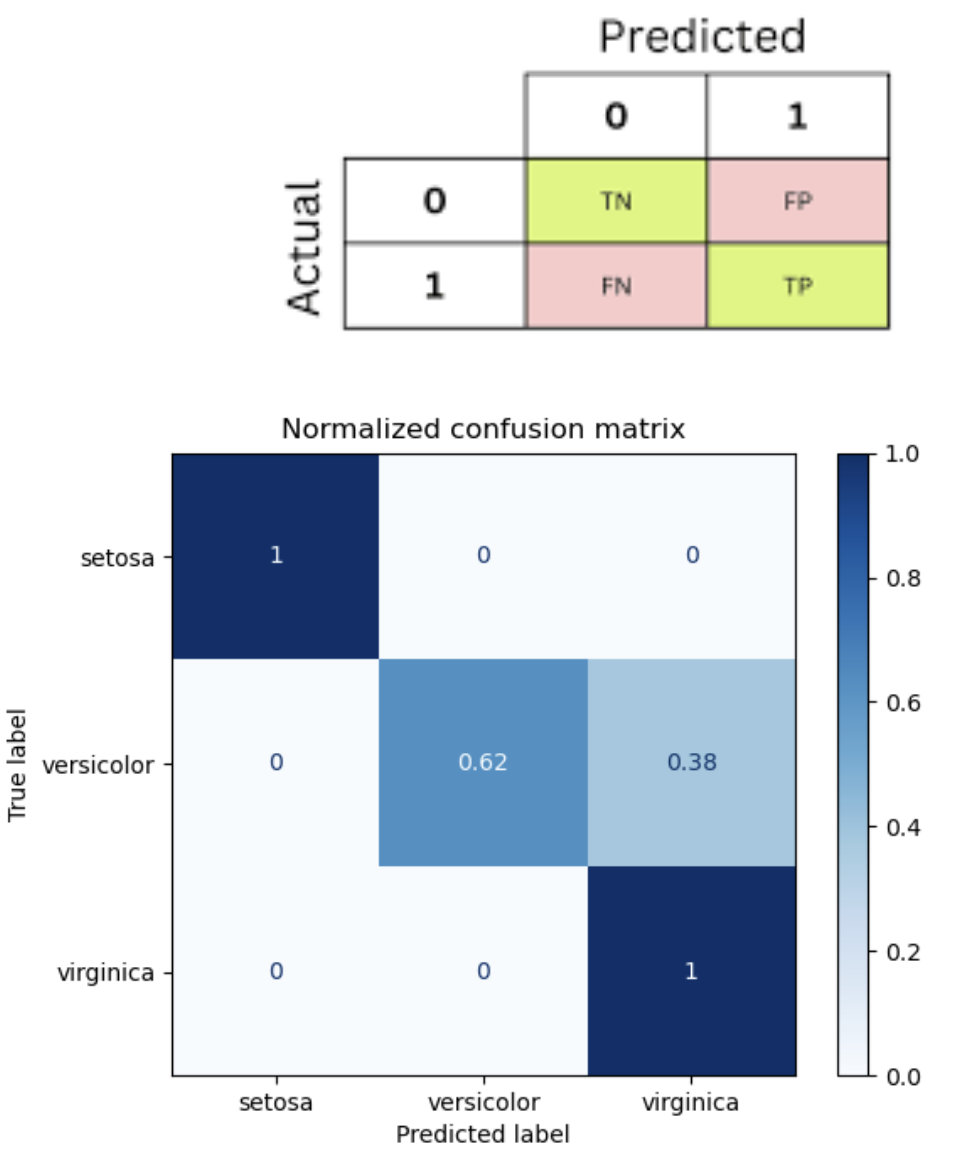

**ВАЖНЫЕ ВЫВОДЫ**

* Разделение на 2 плоскости возможно при наблюдении с разных сторон
* Выбор метода векторизации (преобразовании данных в вектора, которые можно картировать на Евклидово пространство) напрямую влияют на качество классификации: мы хотим создать наборы чисел, которые просто надо разделить подходящей плоскостью
* Также размерность пространства влияет на вероятность успеха (2D проекции часто недостаточно, даже если результат линейный)
* Линейные методы могут быть очень производительными, если использовать трюки (kernel trick), например, производить манипуляции с размерностью




---


* Это линейная функция для нашей гиперплоскости

* **2.04, 0.47, 215.47** – параметры её координат

* Именно эти числа подбираются АВТОМАТИЧЕСКИ в ходе машинного обучения



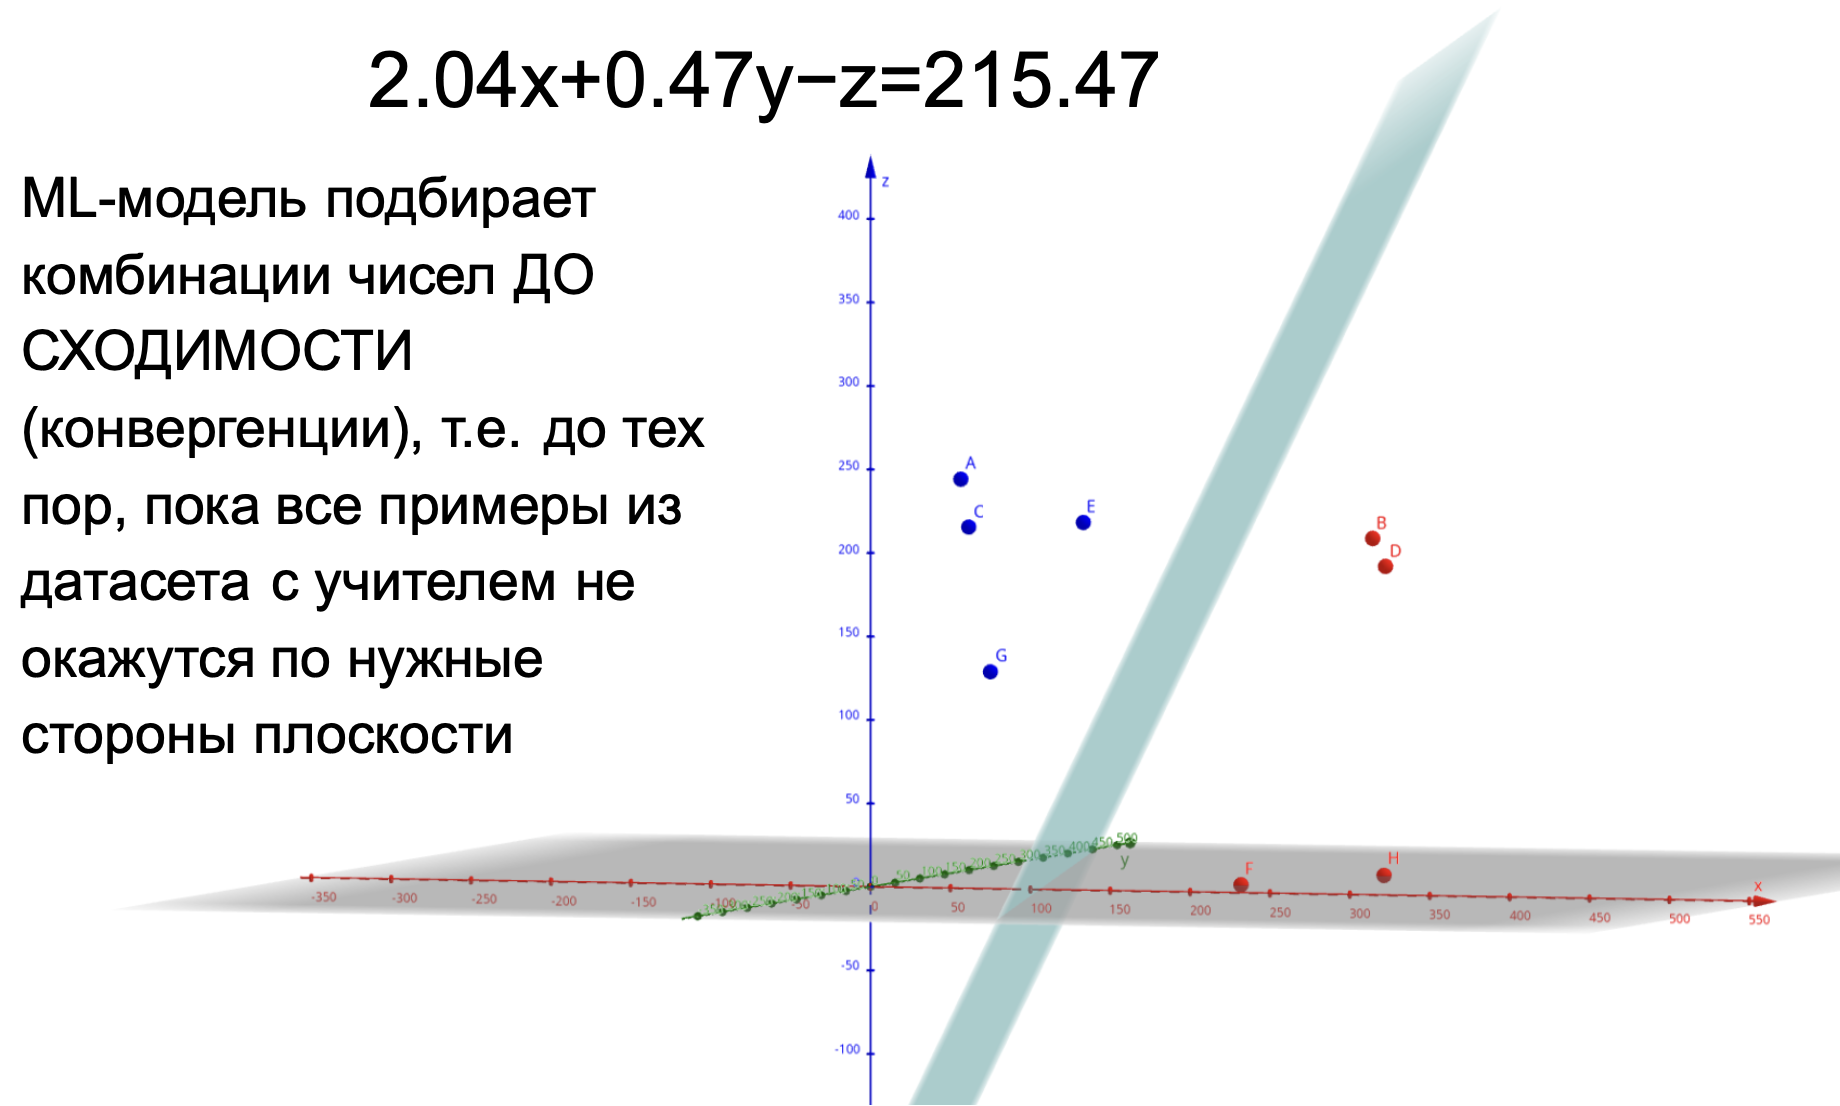